# Loan Default Prediction

**Pipeline Steps:**
1. Data Ingestion
2. Advanced Data Cleaning & Feature Engineering
3. Preprocessing (Scaling & Encoding)
4. Scikit-Learn Baseline Model (HGB)
5. Custom PyTorch Deep Learning Architectures
6. Model Evaluation & Comparison

In [80]:
# Data manipulation and calculations
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Optimization (Genetic Algorithm)
from deap import base, creator, tools, algorithms
import random

# Set visualization style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [81]:
df = pd.read_csv('./loan_data.csv')
display(df.head())
print("\n--- Dataset Info ---")
df.info()
print("\n--- Summary Statistics ---")
display(df.describe())

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


# Cleaning

In [82]:
print(f"Original dataset shape: {df.shape}")

df = df[df['person_age'] <= 90]
df = df[df['person_emp_exp'] <= (df['person_age'] - 14)]
income_99th = df['person_income'].quantile(0.99)
df['person_income'] = np.where(df['person_income'] > income_99th, income_99th, df['person_income'])

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Cleaned dataset shape: {df.shape}")

In [83]:
df['debt_to_income_ratio'] = df['loan_amnt'] / df['person_income']

if 'cb_person_cred_hist_length' in df.columns and 'loan_int_rate' in df.columns:
    df['interest_rate_to_credit_hist'] = df['loan_int_rate'] / (df['cb_person_cred_hist_length'] + 1) # +1 avoids division by zero


auto_reject_conditions = (
    ((df['person_income'] < 10000) & (df['loan_amnt'] > 20000)) |
    (df['debt_to_income_ratio'] > 0.60)
)

df['auto_reject_flag'] = np.where(auto_reject_conditions, 1, 0)
auto_rejected_count = df['auto_reject_flag'].sum()

print(f"Number of applications automatically rejected by business rules (CSP): {auto_rejected_count}")

ml_df = df[df['auto_reject_flag'] == 0].copy()
ml_df = ml_df.drop('auto_reject_flag', axis=1)

print(f"Final dataset shape ready for ML preprocessing: {ml_df.shape}")

# Preprocessing for Deep Learning

In [84]:
categorical_cols = ml_df.select_dtypes(include=['object']).columns
ml_df_encoded = pd.get_dummies(ml_df, columns=categorical_cols, drop_first=True)


X = ml_df_encoded.drop('loan_status', axis=1)
y = ml_df_encoded['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Data Shape: {X_train_scaled.shape}")
print(f"Testing Data Shape: {X_test_scaled.shape}")

In [85]:

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Target tensors need to be reshaped to (N, 1) to match the output of our networks
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Created DataLoaders with batch size: {BATCH_SIZE}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

#Part 4: Modeling & Deep Learning Experiments

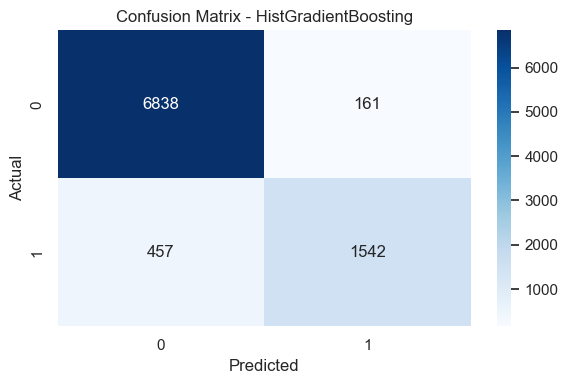

In [86]:
# ==========================================
# HistGradientBoosting
# ==========================================
print("Training HistGradientBoostingClassifier...")

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Train model
hgb_clf = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
hgb_clf.fit(X_train_scaled, y_train)

# Predict
y_pred_hgb = hgb_clf.predict(X_test_scaled)

# Accuracy
hgb_acc = accuracy_score(y_test, y_pred_hgb)
print(f"HistGradientBoosting Accuracy: {hgb_acc:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_hgb))

if 'y_test_tensor' in globals():
    y_true = y_test_tensor.cpu().numpy() if hasattr(y_test_tensor, "cpu") else y_test_tensor.numpy()
else:
    y_true = y_test


# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_hgb)

# Plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - HistGradientBoosting')
plt.tight_layout()
plt.show()

In [87]:
def train_eval_pytorch_model(model, train_loader, X_test_tensor, y_test_tensor, epochs=100, lr=0.001, patience=5):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    X_test_gpu = X_test_tensor.to(device)
    y_test_gpu = y_test_tensor.to(device)
    
    print(f"Training {model.__class__.__name__} on {device}...")
    
    best_loss = float('inf')
    epochs_no_improve = 0
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        epoch_loss = running_loss/len(train_loader)
        
        # --- EARLY STOPPING LOGIC ---
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}!")
            break
            
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f}")
            
    # Evaluation phase
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test_gpu)
        test_preds_binary = (test_predictions > 0.5).float()
        
        correct = (test_preds_binary == y_test_gpu).sum().item()
        accuracy = correct / y_test_gpu.size(0)
        
    print(f"Final Test Accuracy: {accuracy:.4f}\n" + "-"*40)
    return model, accuracy, test_preds_binary.cpu()


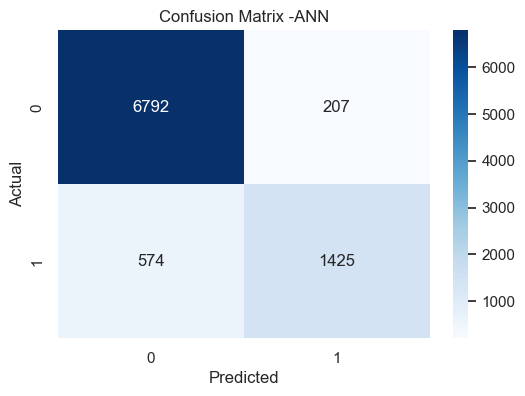

In [88]:
# ==========================================
# ANN
# ==========================================
class LightweightANN(nn.Module):
    def __init__(self, input_dim):
        super(LightweightANN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(16, 8),
            nn.ReLU(),
            
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

input_dim = X_train_scaled.shape[1] 
# Instantiate and Train (Using 100 epochs and patience=5 for Early Stopping)
print("--- Training Baseline ANN ---")
lightweight_model = LightweightANN(input_dim)
_, lightweight_acc, y_pred_light = train_eval_pytorch_model(
    lightweight_model, train_loader, X_test_tensor, y_test_tensor, epochs=100, patience=5
)

cm = confusion_matrix(y_test_tensor.numpy(), y_pred_light.numpy())
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix -ANN')
plt.show()


#Part 5: Optimization & Conclusion

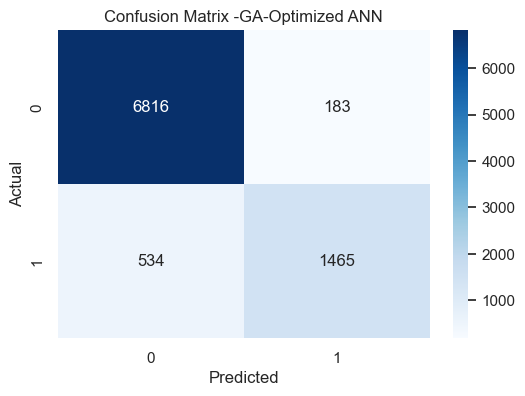

In [89]:
# ==========================================
# Hyperparameter Optimization via Genetic Algorithm
# ==========================================
print("Starting Genetic Algorithm Optimization...")

hidden_sizes = [32, 64, 128, 256]
learning_rates = [0.01, 0.005, 0.001, 0.0005]
if hasattr(creator, "FitnessMax"): del creator.FitnessMax
if hasattr(creator, "Individual"): del creator.Individual

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_hidden", random.randint, 0, len(hidden_sizes)-1)
toolbox.register("attr_lr", random.randint, 0, len(learning_rates)-1)
toolbox.register("individual", tools.initCycle, creator.Individual, (toolbox.attr_hidden, toolbox.attr_lr), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluate_model(individual):
    h_size = hidden_sizes[individual[0]]
    lr = learning_rates[individual[1]]
    class GA_Net(nn.Module):
        def __init__(self, input_dim, hidden):
            super(GA_Net, self).__init__()
            self.net = nn.Sequential(nn.Linear(input_dim, hidden), nn.ReLU(), nn.Linear(hidden, 1), nn.Sigmoid())
        def forward(self, x): return self.net(x)
    model = GA_Net(input_dim, h_size)
    _, acc, _ = train_eval_pytorch_model(model, train_loader, X_test_tensor, y_test_tensor, epochs=10, lr=lr)
    return (acc,)

toolbox.register("evaluate", evaluate_model)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutUniformInt, low=0, up=3, indpb=0.5)
toolbox.register("select", tools.selTournament, tournsize=3)

population = toolbox.population(n=20)
import sys, os
old_stdout = sys.stdout
sys.stdout = open(os.devnull, 'w')
algorithms.eaSimple(population, toolbox, cxpb=0.5, mutpb=0.2, ngen=10, verbose=True)
sys.stdout.close()
sys.stdout = old_stdout

best_ind = tools.selBest(population, 1)[0]
best_h_size = hidden_sizes[best_ind[0]]
best_lr = learning_rates[best_ind[1]]

print(f"GA Optimization Complete! Best H-Size: {best_h_size}, LR: {best_lr}")

class FinalOptimizedNet(nn.Module):
    def __init__(self, input_dim, hidden):
        super(FinalOptimizedNet, self).__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(0.2), nn.Linear(hidden, 1), nn.Sigmoid())
    def forward(self, x): return self.net(x)

final_ga_model = FinalOptimizedNet(input_dim, best_h_size)
_, ga_acc, y_pred_ga = train_eval_pytorch_model(final_ga_model, train_loader, X_test_tensor, y_test_tensor, epochs=30, lr=best_lr)

cm = confusion_matrix(y_test_tensor.numpy(), y_pred_ga.numpy())
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix -GA-Optimized ANN')
plt.show()

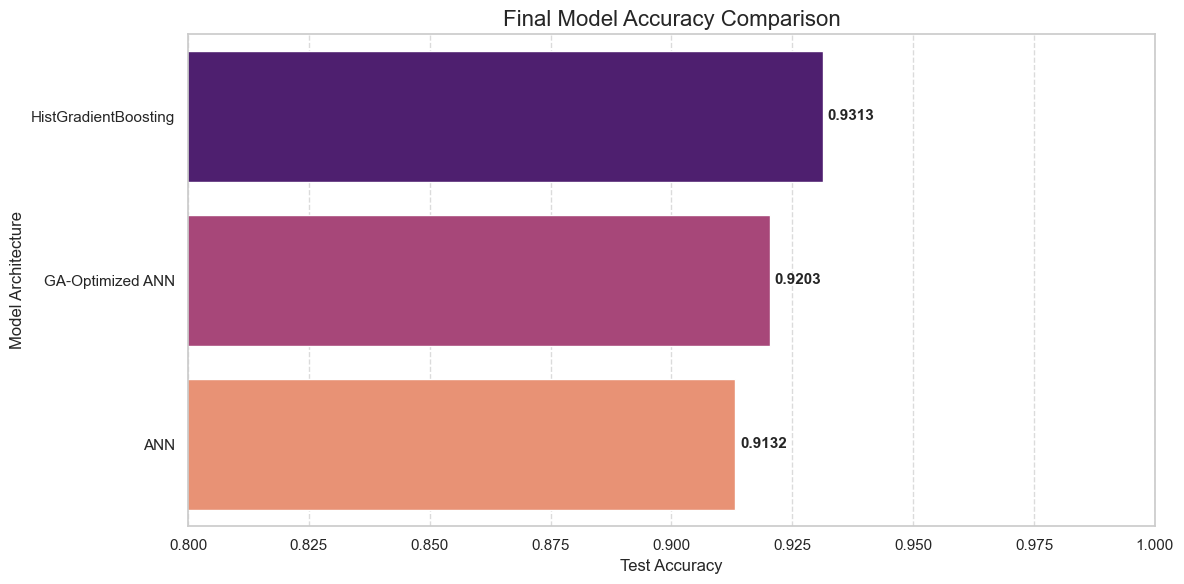

In [90]:
# ==========================================
# Final Model Comparison
# ==========================================
# Collect all accuracies into a DataFrame
results_df = pd.DataFrame({
    'Model': [
        'HistGradientBoosting',
        'ANN',
        'GA-Optimized ANN'
    ],
    'Accuracy': [
        hgb_acc,
        lightweight_acc,
        ga_acc
    ]
})

results_df = results_df.sort_values(by='Accuracy', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='magma')

# Add accuracy labels to the bars
for index, value in enumerate(results_df['Accuracy']):
    plt.text(value + 0.001, index, f'{value:.4f}', va='center', fontsize=11, fontweight='bold')

plt.title('Final Model Accuracy Comparison', fontsize=16)
plt.xlim(0.80, 1.0)
plt.xlabel('Test Accuracy', fontsize=12)
plt.ylabel('Model Architecture', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()